In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from collections import namedtuple
from scipy.special import logsumexp

### The Model

$$Y_t = \beta \exp(X_t/2)V_t$$
$$X_{t+1} = \phi X_t + \sigma W_t $$

$$V_t, W_t \sim N(0,1)$$

In [ ]:
# simulate
def simulate(T, beta, phi, sigma, seed=0):
    np.random.seed(seed)
    x = np.zeros(T)
    x[0] = np.random.normal(0, )

    for t in range(1, T):
        x[t] = np.random.normal(loc=phi * x[t - 1], scale=sigma)
    y = beta * np.exp(x / 2) * np.random.normal(size=T)

    return x, y

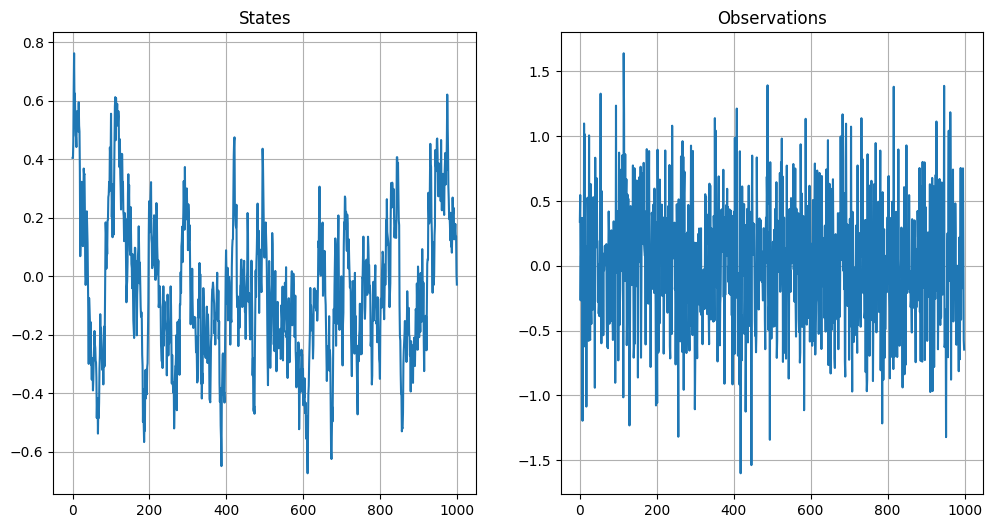

In [ ]:
T = 1000  # time steps
beta = 0.5
phi = 0.9
sigma = 0.1
states, observations = simulate(T, beta, phi, sigma)
fig, ax = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)
ax[0].plot(states)
ax[0].set_title("States")
ax[0].grid()
ax[1].plot(observations)
ax[1].set_title("Observations")
ax[1].grid()

### Graph generation code

In [59]:
def plot_param_estimation(guesses, N, ess_threshold="None"):
    guesses = np.array(guesses)
    guesses_t = guesses.T

    betas = guesses_t[0]
    phis = guesses_t[1]
    sigmas = guesses_t[2]

    fig, ax = plt.subplots()

    ax.plot(betas, label="beta", color="red")
    ax.hlines(
        y=beta,
        xmin=0,
        xmax=len(betas),
        label="true beta",
        linestyle="dashed",
        color="red",
    )

    ax.plot(phis, label="phi", color="green")
    ax.hlines(
        y=phi,
        xmin=0,
        xmax=len(phis),
        label="true phi",
        linestyle="dashed",
        color="green",
    )

    ax.plot(sigmas, label="sigma", color="blue")
    ax.hlines(
        y=sigma,
        xmin=0,
        xmax=len(phis),
        label="true sigma",
        linestyle="dashed",
        color="blue",
    )

    fig.legend()
    ax.grid()
    ax.set_title(f"{N} particles, ESS threshold: {ess_threshold}")
    fig.set_figheight(6)
    fig.set_figwidth(10)

### Algorithm

Functions defining transition probabilties and gradients

In [ ]:
def q(y, x, beta):
    return st.norm.pdf(y, loc=0, scale=beta * np.exp(x / 2))


def log_q(y, x, beta):
    return st.norm.logpdf(y, loc=0, scale=beta * np.exp(x / 2))


def p(x_2, x_1, phi, sigma):
    return st.norm.pdf(x_2, loc=phi * x_1, scale=sigma)


def d_beta(beta, y, x):
    return q(y, x, beta) * (-1 / beta + y**2 / beta**3 / np.exp(x))


def d_phi(phi, sigma, x2, x1):
    return p(x2, x1, phi, sigma) * (x2 - phi * x1) / sigma**2 * x1


def d_sigma(phi, sigma, x2, x1):
    return p(x2, x1, phi, sigma) * (-1 / sigma + (x2 - phi * x1) ** 2 / sigma**3)

Step size

In [47]:
def a(n):
    return 0.05 / (n + 1) ** 0.6

Particle resampling and propogation with ESS check

In [ ]:
def systematic_resample(particles, N, w):
    N = len(particles)

    cdf = np.cumsum(w)
    cdf[-1] = 1.0  # numerical safety

    u0 = np.random.uniform(0.0, 1.0 / N)
    u = u0 + np.arange(N) / N
    idx = np.searchsorted(cdf, u)
    return particles[idx]


def resample_propogate_systematic(
    N, observation, particles, beta, phi, sigma, ess_threshold=0.7
):
    logw = log_q(observation, particles, beta)
    logw -= logsumexp(logw)
    w = np.exp(logw)
    s = np.sum(w)

    if s == 0 or not np.isfinite(s):
        w = np.ones(N) / N
    else:
        w /= s

    ess = 1.0 / np.sum(w**2)

    # ess check
    if ess < ess_threshold * N:
        # resample if variance above threshold
        ancestors = systematic_resample(particles, N, w)
    else:
        # no resampling
        ancestors = particles

    # propogate
    particles = np.random.normal(loc=phi * ancestors, scale=sigma)

    return particles

In [50]:
def estimate_params(
    T,
    observations,
    initial_beta=0.7,
    initial_phi=0.5,
    initial_sigma=0.2,
    N=1000,
    seed=0,
    ess_threshold=0.9,
):
    np.random.seed(seed)
    beta, phi, sigma = initial_beta, initial_phi, initial_sigma
    d = 3  # number of parameters
    Params = namedtuple("Params", "beta phi sigma")
    params = Params(0, 1, 2)
    particles = np.random.normal(loc=0, size=N)

    weights = 1 / N * np.ones((d, N))

    evolution = [(beta, phi, sigma)]

    for j in range(T - 1):
        observation = observations[j]
        next_particles = resample_propogate_systematic(
            N, observation, particles, beta, phi, sigma, ess_threshold
        )
        next_observation = observations[j + 1]
        new_weights = np.empty((d, N))
        for i in range(N):
            normaliser = np.sum(
                (
                    p(next_particles[i], particles, phi, sigma)
                    * q(observation, particles, beta)
                )
            )
            if normaliser == 0:
                continue
            new_weights[params.beta][i] = (
                np.sum(
                    p(next_particles[i], particles, phi, sigma)
                    * d_beta(beta, observation, particles)
                )
                + np.sum(
                    p(next_particles[i], particles, phi, sigma)
                    * q(observation, particles, beta)
                    * weights[params.beta]
                )
            ) / normaliser
            new_weights[params.phi][i] = (
                np.sum(
                    d_phi(phi, sigma, next_particles[i], particles)
                    * q(observation, particles, beta)
                )
                + np.sum(
                    p(next_particles[i], particles, phi, sigma)
                    * q(observation, particles, beta)
                    * weights[params.phi]
                )
            ) / normaliser
            new_weights[params.sigma][i] = (
                np.sum(
                    d_sigma(phi, sigma, next_particles[i], particles)
                    * q(observation, particles, beta)
                )
                + np.sum(
                    p(next_particles[i], particles, phi, sigma)
                    * q(observation, particles, beta)
                    * weights[params.sigma]
                )
            ) / normaliser
        new_weights = new_weights - np.reshape(np.mean(new_weights, axis=1), (d, 1))
        normaliser = np.sum(q(next_observation, next_particles, beta))
        if normaliser != 0:  # normaliser == 0 iff all probabilities are zero
            phi += (
                a(j)
                * np.sum(
                    q(next_observation, next_particles, beta) * new_weights[params.phi]
                )
                / normaliser
            )
            phi = min(max(phi, 0.01), 1)
            sigma += (
                a(j)
                * np.sum(
                    q(next_observation, next_particles, beta)
                    * new_weights[params.sigma]
                )
                / normaliser
            )
            sigma = min(max(sigma, 0.01), 1.5)
            beta += (
                a(j)
                * (
                    np.sum(
                        q(next_observation, next_particles, beta)
                        * new_weights[params.beta]
                    )
                    + np.sum(d_beta(beta, next_observation, next_particles))
                )
                / normaliser
            )
            beta = min(max(beta, 0.01), 1.5)

        weights = new_weights
        evolution.append((beta, phi, sigma))

        # print("params:",evolution)
        print(f"Iteration {j + 1}/{T - 1} beta:{beta}, phi:{phi}, sigma:{sigma})")

        particles = next_particles
    return evolution


def transition_matrix(x2, x1, phi, sigma):
    """
    x2: (N,)
    x1: (N,)
    returns: (N, N) matrix with P[i,j] = p(x2[i] | x1[j])
    """
    return st.norm.pdf(x2[:, None], loc=phi * x1[None, :], scale=sigma)


def estimate_params_vec(
    T,
    observations,
    initial_beta=0.7,
    initial_phi=0.5,
    initial_sigma=0.2,
    N=1000,
    seed=0,
    ess_threshold=0.9,
):
    np.random.seed(seed)

    beta, phi, sigma = initial_beta, initial_phi, initial_sigma
    d = 3
    Params = namedtuple("Params", "beta phi sigma")
    params = Params(0, 1, 2)

    particles = np.random.normal(size=N)
    weights = np.zeros((d, N))
    evolution = [(beta, phi, sigma)]

    for j in range(T - 1):
        y = observations[j]
        y_next = observations[j + 1]

        # ---- propagate particles ----
        next_particles = resample_propogate_systematic(
            N, y, particles, beta, phi, sigma, ess_threshold
        )

        # ---- densities ----
        Q = q(y, particles, beta)  # (N,)
        P = transition_matrix(next_particles, particles, phi, sigma)  # (N,N)

        PQ = P * Q[None, :]
        normalisers = PQ.sum(axis=1)  # (N,)

        # ---- derivatives ----
        dB = d_beta(beta, y, particles)
        dP_phi = d_phi(phi, sigma, next_particles[:, None], particles[None, :])
        dP_sig = d_sigma(phi, sigma, next_particles[:, None], particles[None, :])

        # ---- recursion ----
        new_weights = np.zeros_like(weights)

        valid = normalisers > 0

        new_weights[params.beta, valid] = (
            (P[valid] @ dB) + (PQ[valid] @ weights[params.beta])
        ) / normalisers[valid]

        new_weights[params.phi, valid] = (
            (dP_phi[valid] @ Q) + (PQ[valid] @ weights[params.phi])
        ) / normalisers[valid]

        new_weights[params.sigma, valid] = (
            (dP_sig[valid] @ Q) + (PQ[valid] @ weights[params.sigma])
        ) / normalisers[valid]

        # ---- centering ----
        new_weights -= new_weights.mean(axis=1, keepdims=True)

        # ---- score update ----
        Q_next = q(y_next, next_particles, beta)
        Z = Q_next.sum()

        if Z > 0:
            phi += a(j) * (Q_next @ new_weights[params.phi]) / Z
            phi = np.clip(phi, 0.01, 0.99)

            sigma += a(j) * (Q_next @ new_weights[params.sigma]) / Z
            sigma = np.clip(sigma, 0.01, 1.5)

            beta += (
                a(j)
                * (
                    (Q_next @ new_weights[params.beta])
                    + d_beta(beta, y_next, next_particles).sum()
                )
                / Z
            )
            beta = np.clip(beta, 0.01, 1.5)

        weights = new_weights
        particles = next_particles
        evolution.append((beta, phi, sigma))

        print(
            f"Iteration {j + 1}/{T - 1} "
            f"beta={beta:.3f}, phi={phi:.3f}, sigma={sigma:.3f}"
        )

    return evolution

In [53]:
guesses = estimate_params_vec(T=300, observations=observations, N=3000, ess_threshold=0.9)

Iteration 1/299 beta=0.681, phi=0.491, sigma=0.194
Iteration 2/299 beta=0.644, phi=0.492, sigma=0.194
Iteration 3/299 beta=0.607, phi=0.494, sigma=0.194
Iteration 4/299 beta=0.574, phi=0.495, sigma=0.193
Iteration 5/299 beta=0.543, phi=0.495, sigma=0.192
Iteration 6/299 beta=0.527, phi=0.495, sigma=0.191
Iteration 7/299 beta=0.638, phi=0.495, sigma=0.198
Iteration 8/299 beta=0.616, phi=0.495, sigma=0.199
Iteration 9/299 beta=0.596, phi=0.495, sigma=0.201
Iteration 10/299 beta=0.599, phi=0.495, sigma=0.199
Iteration 11/299 beta=0.643, phi=0.494, sigma=0.197
Iteration 12/299 beta=0.627, phi=0.494, sigma=0.198
Iteration 13/299 beta=0.653, phi=0.494, sigma=0.196
Iteration 14/299 beta=0.647, phi=0.494, sigma=0.195
Iteration 15/299 beta=0.645, phi=0.494, sigma=0.194
Iteration 16/299 beta=0.631, phi=0.494, sigma=0.195
Iteration 17/299 beta=0.658, phi=0.493, sigma=0.194
Iteration 18/299 beta=0.646, phi=0.493, sigma=0.195
Iteration 19/299 beta=0.633, phi=0.493, sigma=0.195
Iteration 20/299 beta

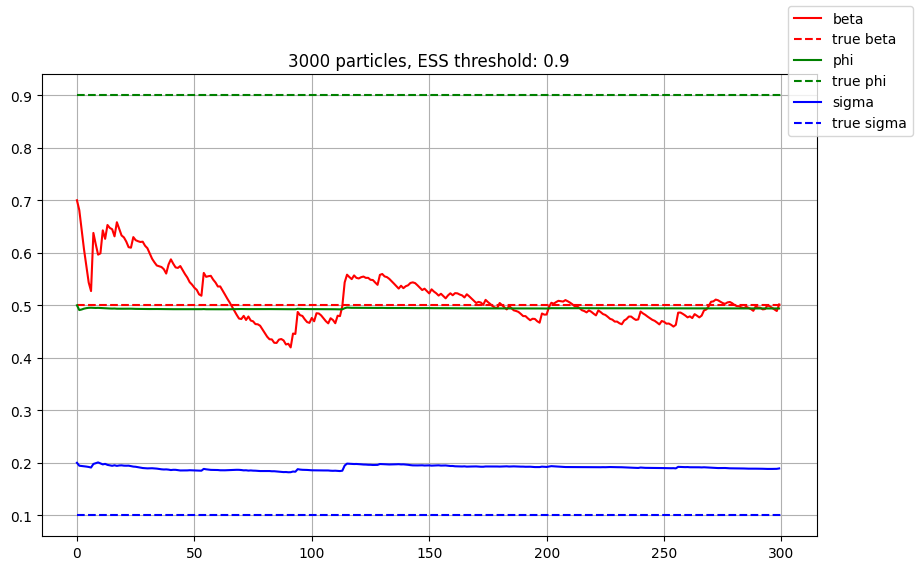

In [60]:
plot_param_estimation(guesses, N=3000, ess_threshold=0.9)

Variable step size for each parameter

In [77]:
def a_flex(n, alpha=0.6):
    return 0.1 / (n + 1) ** alpha

In [78]:
def estimate_params_vectorised_step_sizes(
    T,
    observations,
    initial_beta=0.7,
    initial_phi=0.5,
    initial_sigma=0.2,
    N=1000,
    seed=0,
    ess_threshold=0.9,
    a_beta_exp=0.6,
    a_phi_exp=0.6,
    a_sigma_exp=0.6,
):
    np.random.seed(seed)
    beta, phi, sigma = initial_beta, initial_phi, initial_sigma
    d = 3
    Params = namedtuple("Params", "beta phi sigma")
    params = Params(0, 1, 2)

    particles = np.random.normal(size=N)
    weights = np.zeros((d, N))
    evolution = [(beta, phi, sigma)]

    for j in range(T - 1):
        y = observations[j]
        y_next = observations[j + 1]

        # --- propagate particles ---
        next_particles = resample_propogate_systematic(
            N, y, particles, beta, phi, sigma, ess_threshold
        )

        # --- densities ---
        Q = q(y, particles, beta)
        P = transition_matrix(next_particles, particles, phi, sigma)
        PQ = P * Q[None, :]
        normalisers = PQ.sum(axis=1)
        valid = normalisers > 0

        # --- derivatives ---
        dB = d_beta(beta, y, particles)
        dP_phi = d_phi(phi, sigma, next_particles[:, None], particles[None, :])
        dP_sig = d_sigma(phi, sigma, next_particles[:, None], particles[None, :])

        # --- update weights ---
        new_weights = np.zeros_like(weights)

        new_weights[params.beta, valid] = (
            (P[valid] @ dB) + (PQ[valid] @ weights[params.beta])
        ) / normalisers[valid]

        new_weights[params.phi, valid] = (
            (dP_phi[valid] @ Q) + (PQ[valid] @ weights[params.phi])
        ) / normalisers[valid]

        new_weights[params.sigma, valid] = (
            (dP_sig[valid] @ Q) + (PQ[valid] @ weights[params.sigma])
        ) / normalisers[valid]

        # --- centering (only β and σ) ---
        new_weights[params.beta] -= new_weights[params.beta].mean()
        new_weights[params.sigma] -= new_weights[params.sigma].mean()
        new_weights[params.phi] -= new_weights[params.phi].mean()

        # --- parameter updates with individual step sizes ---
        Q_next = q(y_next, next_particles, beta)
        Z = Q_next.sum()

        if Z > 0:
            beta += (
                a_flex(j, a_beta_exp)
                * (
                    (Q_next @ new_weights[params.beta])
                    + d_beta(beta, y_next, next_particles).sum()
                )
                / Z
            )
            beta = np.clip(beta, 0.01, 1.0)

            phi += a_flex(j, a_phi_exp) * (Q_next @ new_weights[params.phi]) / Z
            phi = np.clip(phi, 0.01, 1.0)

            sigma += a_flex(j, a_sigma_exp) * (Q_next @ new_weights[params.sigma]) / Z
            sigma = np.clip(sigma, 0.01, 1.0)

        weights = new_weights
        particles = next_particles
        evolution.append((beta, phi, sigma))

        print(f"Iter {j + 1}/{T - 1} beta={beta:.3f}, phi={phi:.3f}, sigma={sigma:.3f}")

    return evolution

beta clipped to (0,1), sigma clipped to (0,1), phi clipped (0,1)

In [79]:
guesses = estimate_params_vectorised_step_sizes(
    T=400,
    observations=observations,
    N=2000,
    ess_threshold=0.9,
    initial_sigma=0.2,
    initial_phi=0.7,
    a_beta_exp=0.6,
    a_phi_exp=0.3,
    a_sigma_exp=0.4,
)

Iter 1/399 beta=0.672, phi=0.676, sigma=0.190
Iter 2/399 beta=0.611, phi=0.681, sigma=0.192
Iter 3/399 beta=0.542, phi=0.694, sigma=0.193
Iter 4/399 beta=0.478, phi=0.700, sigma=0.190
Iter 5/399 beta=0.411, phi=0.706, sigma=0.186
Iter 6/399 beta=0.399, phi=0.702, sigma=0.177
Iter 7/399 beta=0.866, phi=0.758, sigma=0.351
Iter 8/399 beta=0.837, phi=0.756, sigma=0.345
Iter 9/399 beta=0.809, phi=0.757, sigma=0.343
Iter 10/399 beta=0.800, phi=0.754, sigma=0.334
Iter 11/399 beta=0.822, phi=0.746, sigma=0.324
Iter 12/399 beta=0.801, phi=0.746, sigma=0.325
Iter 13/399 beta=0.816, phi=0.738, sigma=0.313
Iter 14/399 beta=0.805, phi=0.735, sigma=0.308
Iter 15/399 beta=0.798, phi=0.731, sigma=0.302
Iter 16/399 beta=0.780, phi=0.738, sigma=0.310
Iter 17/399 beta=0.798, phi=0.724, sigma=0.293
Iter 18/399 beta=0.782, phi=0.728, sigma=0.300
Iter 19/399 beta=0.764, phi=0.734, sigma=0.307
Iter 20/399 beta=0.755, phi=0.734, sigma=0.303
Iter 21/399 beta=0.742, phi=0.736, sigma=0.303
Iter 22/399 beta=0.725

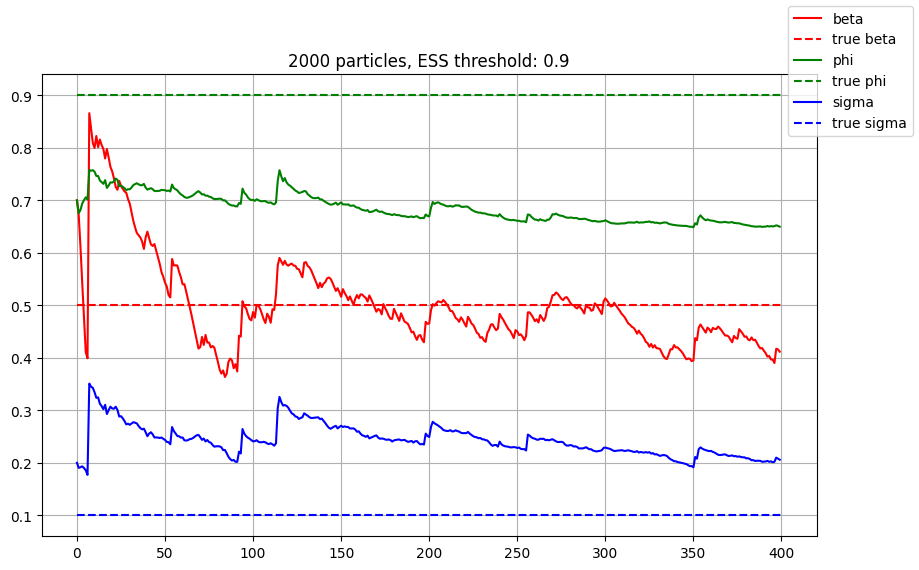

In [80]:
plot_param_estimation(guesses, N=2000, ess_threshold=0.9)

Diff ess for each parameter

In [89]:
# ------------------------------
# Vectorised parameter estimation with per-parameter ESS
# ------------------------------
def estimate_params_vec_per_parameter_ess(
    T,
    observations,
    initial_beta=0.7,
    initial_phi=0.5,
    initial_sigma=0.2,
    N=1000,
    seed=0,
    a_beta_exp=0.6,
    a_phi_exp=0.3,
    a_sigma_exp=0.6,
    ess_thresh_beta=0.6,
    ess_thresh_phi=0.9,
    ess_thresh_sigma=0.7,
):
    np.random.seed(seed)

    beta, phi, sigma = initial_beta, initial_phi, initial_sigma
    d = 3
    Params = namedtuple("Params", "beta phi sigma")
    params = Params(0, 1, 2)

    particles = np.random.normal(size=N)
    weights = np.zeros((d, N))
    evolution = [(beta, phi, sigma)]

    for j in range(T - 1):
        y = observations[j]
        y_next = observations[j + 1]

        # -------------------------
        # compute weights
        # -------------------------
        logw = log_q(y, particles, beta)
        logw -= logsumexp(logw)
        w = np.exp(logw)
        w /= w.sum()

        # -------------------------
        # compute per-parameter effective ESS
        # -------------------------
        score_beta = d_beta(beta, y, particles)
        score_phi = (
            (particles - phi * particles) * particles / sigma**2
        )  # simplified vector
        score_sigma = (
            -1 / sigma + (particles - phi * particles) ** 2 / sigma**2
        )  # simplified

        def ess(w_eff):
            return (w_eff.sum()) ** 2 / (np.sum(w_eff**2) + 1e-16)

        ess_beta = ess(w * np.abs(score_beta))
        ess_phi = ess(w * np.abs(score_phi))
        ess_sigma = ess(w * np.abs(score_sigma))

        # -------------------------
        # resample if any ESS below threshold
        # -------------------------
        resample_flag = (
            (ess_beta < ess_thresh_beta * N)
            or (ess_phi < ess_thresh_phi * N)
            or (ess_sigma < ess_thresh_sigma * N)
        )

        if resample_flag:
            ancestors = systematic_resample(particles, N, w)
        else:
            ancestors = particles

        # -------------------------
        # propagate
        # -------------------------
        particles_next = np.random.normal(loc=phi * ancestors, scale=sigma)

        # -------------------------
        # vectorised derivatives for weight recursion
        # -------------------------
        Q = q(y, particles, beta)
        P = transition_matrix(particles_next, particles, phi, sigma)
        PQ = P * Q[None, :]
        normalisers = PQ.sum(axis=1)
        valid = normalisers > 0

        dB = d_beta(beta, y, particles)
        dP_phi = d_phi(phi, sigma, particles_next[:, None], particles[None, :])
        dP_sig = d_sigma(phi, sigma, particles_next[:, None], particles[None, :])

        new_weights = np.zeros((d, N))

        new_weights[params.beta, valid] = (
            P[valid] @ dB + PQ[valid] @ weights[params.beta]
        ) / normalisers[valid]
        new_weights[params.phi, valid] = (
            dP_phi[valid] @ Q + PQ[valid] @ weights[params.phi]
        ) / normalisers[valid]
        new_weights[params.sigma, valid] = (
            dP_sig[valid] @ Q + PQ[valid] @ weights[params.sigma]
        ) / normalisers[valid]

    
        new_weights[params.beta] -= new_weights[params.beta].mean()
        new_weights[params.sigma] -= new_weights[params.sigma].mean()
        new_weights[params.phi] -= new_weights[params.phi].mean()

        # -------------------------
        # SGD parameter updates with per-parameter step sizes
        # -------------------------
        Q_next = q(y_next, particles_next, beta)
        Z = Q_next.sum()
        if Z > 0:
            beta += (
                a_flex(j, a_beta_exp)
                * (
                    (Q_next @ new_weights[params.beta])
                    + d_beta(beta, y_next, particles_next).sum()
                )
                / Z
            )
            beta = np.clip(beta, 0.01, 1.0)

            phi += a_flex(j, a_phi_exp) * (Q_next @ new_weights[params.phi]) / Z
            phi = np.clip(phi, 0.01, 1.0)

            sigma += a_flex(j, a_sigma_exp) * (Q_next @ new_weights[params.sigma]) / Z
            sigma = np.clip(sigma, 0.01, 1.0)

        weights = new_weights
        particles = particles_next
        evolution.append((beta, phi, sigma))

        print(f"Iter {j + 1}/{T - 1} beta={beta:.3f}, phi={phi:.3f}, sigma={sigma:.3f}")

    return evolution


In [90]:
guesses = estimate_params_vec_per_parameter_ess(
    T=400,
    observations=observations,
    N=2000,
    initial_sigma=0.2,
    initial_phi=0.7,
    a_beta_exp=0.6,
    a_phi_exp=0.3,
    a_sigma_exp=0.4,
)

Iter 1/399 beta=0.686, phi=0.682, sigma=0.193
Iter 2/399 beta=0.623, phi=0.697, sigma=0.194
Iter 3/399 beta=0.553, phi=0.731, sigma=0.205
Iter 4/399 beta=0.489, phi=0.762, sigma=0.217
Iter 5/399 beta=0.424, phi=0.797, sigma=0.234
Iter 6/399 beta=0.421, phi=0.793, sigma=0.224
Iter 7/399 beta=0.812, phi=0.683, sigma=0.294
Iter 8/399 beta=0.783, phi=0.699, sigma=0.294
Iter 9/399 beta=0.755, phi=0.715, sigma=0.304
Iter 10/399 beta=0.749, phi=0.714, sigma=0.296
Iter 11/399 beta=0.784, phi=0.690, sigma=0.274
Iter 12/399 beta=0.761, phi=0.696, sigma=0.275
Iter 13/399 beta=0.782, phi=0.684, sigma=0.260
Iter 14/399 beta=0.770, phi=0.684, sigma=0.256
Iter 15/399 beta=0.762, phi=0.683, sigma=0.253
Iter 16/399 beta=0.740, phi=0.690, sigma=0.262
Iter 17/399 beta=0.768, phi=0.676, sigma=0.241
Iter 18/399 beta=0.749, phi=0.679, sigma=0.243
Iter 19/399 beta=0.728, phi=0.684, sigma=0.249
Iter 20/399 beta=0.720, phi=0.685, sigma=0.248
Iter 21/399 beta=0.705, phi=0.689, sigma=0.252
Iter 22/399 beta=0.687

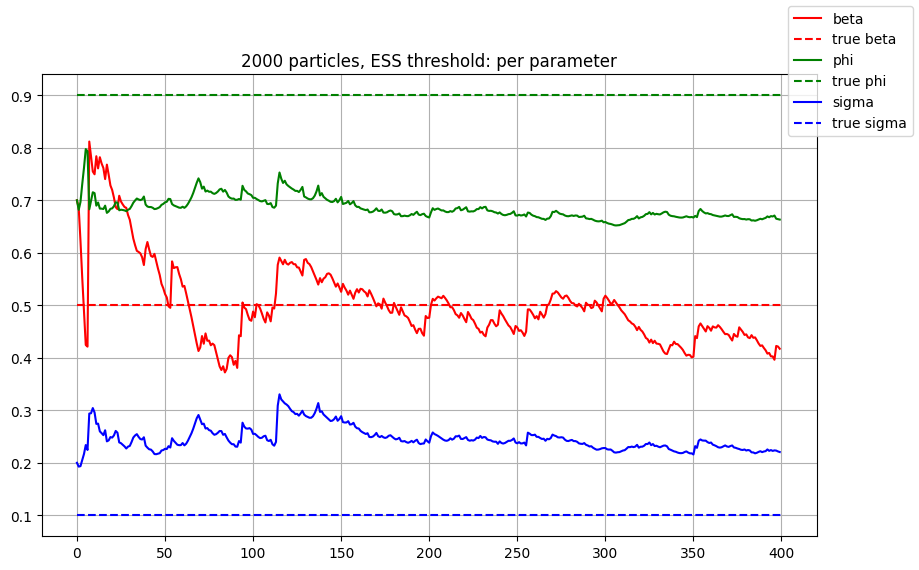

In [91]:
plot_param_estimation(guesses, N=2000, ess_threshold="per parameter")

In [94]:
guesses = estimate_params_vec_per_parameter_ess(
    T=400,
    observations=observations,
    N=2000,
    initial_sigma=0.2,
    initial_phi=0.6,
    a_beta_exp=0.7,
    a_phi_exp=0.3,
    a_sigma_exp=0.3,
)

Iter 1/399 beta=0.679, phi=0.586, sigma=0.193
Iter 2/399 beta=0.615, phi=0.599, sigma=0.193
Iter 3/399 beta=0.546, phi=0.619, sigma=0.201
Iter 4/399 beta=0.487, phi=0.637, sigma=0.215


KeyboardInterrupt: 

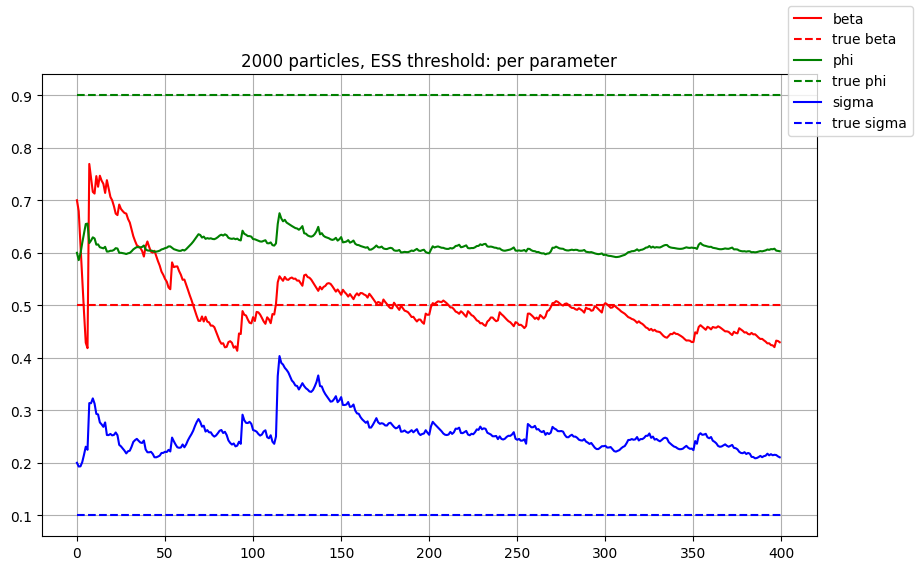

In [93]:
plot_param_estimation(guesses, N=2000, ess_threshold="per parameter")

Particle rejuvination

In [95]:
def rejuvenate_particles(particles, h=0.1):
    """
    Kernel roughening / rejuvenation
    """
    N = len(particles)
    var = np.var(particles)
    if var == 0 or not np.isfinite(var):
        return particles
    noise = np.random.normal(
        loc=0.0,
        scale=h * np.sqrt(var),
        size=N
    )
    return particles + noise


def resample_propogate_systematic(
    N, observation, particles, beta, phi, sigma, ess_threshold=0.7
):
    logw = log_q(observation, particles, beta)
    logw -= logsumexp(logw)
    w = np.exp(logw)
    s = np.sum(w)

    if s == 0 or not np.isfinite(s):
        w = np.ones(N) / N
    else:
        w /= s

    ess = 1.0 / np.sum(w**2)

    # ess check
    if ess < ess_threshold * N:
        # resample if variance above threshold
        ancestors = systematic_resample(particles, N, w)
    else:
        # no resampling
        ancestors = particles

    # propogate
    particles = np.random.normal(loc=phi * ancestors, scale=sigma)

    # rejuvinate particles
    particles = rejuvenate_particles(
        particles,
        h=0.1  # 0.05–0.2 recommended
    )
    return particles

In [ ]:
guesses = estimate_params_vec_per_parameter_ess(
    T=400,
    observations=observations,
    N=2000,
    initial_sigma=0.2,
    initial_phi=0.6,
    a_beta_exp=0.7,
    a_phi_exp=0.3,
    a_sigma_exp=0.3,
)

Iter 1/399 beta=0.679, phi=0.586, sigma=0.193
Iter 2/399 beta=0.615, phi=0.599, sigma=0.193
Iter 3/399 beta=0.546, phi=0.619, sigma=0.201
Iter 4/399 beta=0.487, phi=0.637, sigma=0.215
Iter 5/399 beta=0.429, phi=0.655, sigma=0.231
Iter 6/399 beta=0.418, phi=0.656, sigma=0.225
Iter 7/399 beta=0.769, phi=0.619, sigma=0.314
Iter 8/399 beta=0.742, phi=0.623, sigma=0.313
Iter 9/399 beta=0.716, phi=0.629, sigma=0.323
Iter 10/399 beta=0.713, phi=0.627, sigma=0.313
Iter 11/399 beta=0.746, phi=0.615, sigma=0.293
Iter 12/399 beta=0.726, phi=0.616, sigma=0.292
Iter 13/399 beta=0.747, phi=0.611, sigma=0.277
Iter 14/399 beta=0.737, phi=0.610, sigma=0.273
Iter 15/399 beta=0.731, phi=0.608, sigma=0.268
Iter 16/399 beta=0.714, phi=0.611, sigma=0.277
Iter 17/399 beta=0.738, phi=0.602, sigma=0.253
Iter 18/399 beta=0.723, phi=0.602, sigma=0.253
Iter 19/399 beta=0.706, phi=0.604, sigma=0.255
Iter 20/399 beta=0.700, phi=0.604, sigma=0.252
Iter 21/399 beta=0.689, phi=0.605, sigma=0.253
Iter 22/399 beta=0.675

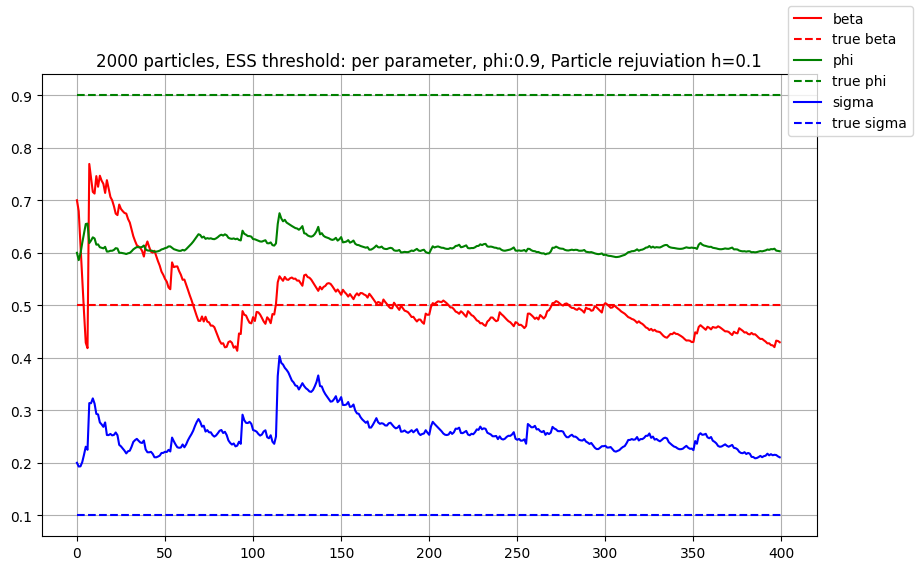

In [98]:
plot_param_estimation(guesses, N=2000, ess_threshold="per parameter, phi:0.9, Particle rejuviation h=0.1")

In [ ]:
guesses = estimate_params_vec_per_parameter_ess(
    T=400,
    observations=observations,
    N=2000,
    initial_sigma=0.2,
    initial_phi=0.6,
    a_beta_exp=0.7,
    a_phi_exp=0.3,
    a_sigma_exp=0.3,
)

Liu west shrinkage

In [99]:
def liu_west_shrinkage(particles, h=0.1):
    """
    Liu–West shrinkage for particle rejuvenation
    """
    mean = np.mean(particles)
    var = np.var(particles)

    if var == 0 or not np.isfinite(var):
        return particles

    a = np.sqrt(1 - h**2)
    noise = np.random.normal(
        loc=0.0,
        scale=h * np.sqrt(var),
        size=len(particles)
    )

    return a * particles + (1 - a) * mean + noise

In [100]:
def resample_propogate_systematic(
    N, observation, particles, beta, phi, sigma, ess_threshold=0.7
):
    logw = log_q(observation, particles, beta)
    logw -= logsumexp(logw)
    w = np.exp(logw)
    s = np.sum(w)

    if s == 0 or not np.isfinite(s):
        w = np.ones(N) / N
    else:
        w /= s

    ess = 1.0 / np.sum(w**2)

    # ess check
    if ess < ess_threshold * N:
        # resample if variance above threshold
        ancestors = systematic_resample(particles, N, w)
    else:
        # no resampling
        ancestors = particles

    # propogate
    particles = np.random.normal(loc=phi * ancestors, scale=sigma)

    # rejuvinate particles
    particles = liu_west_shrinkage(
        particles,
        h=0.1  # 0.05–0.2 recommended
    )
    return particles

In [101]:
guesses = estimate_params_vec_per_parameter_ess(
    T=400,
    observations=observations,
    N=2000,
    initial_sigma=0.2,
    initial_phi=0.6,
    a_beta_exp=0.7,
    a_phi_exp=0.3,
    a_sigma_exp=0.3,
)

Iter 1/399 beta=0.679, phi=0.586, sigma=0.193
Iter 2/399 beta=0.615, phi=0.599, sigma=0.193
Iter 3/399 beta=0.546, phi=0.619, sigma=0.201
Iter 4/399 beta=0.487, phi=0.637, sigma=0.215
Iter 5/399 beta=0.429, phi=0.655, sigma=0.231
Iter 6/399 beta=0.418, phi=0.656, sigma=0.225
Iter 7/399 beta=0.769, phi=0.619, sigma=0.314
Iter 8/399 beta=0.742, phi=0.623, sigma=0.313
Iter 9/399 beta=0.716, phi=0.629, sigma=0.323
Iter 10/399 beta=0.713, phi=0.627, sigma=0.313
Iter 11/399 beta=0.746, phi=0.615, sigma=0.293
Iter 12/399 beta=0.726, phi=0.616, sigma=0.292
Iter 13/399 beta=0.747, phi=0.611, sigma=0.277
Iter 14/399 beta=0.737, phi=0.610, sigma=0.273
Iter 15/399 beta=0.731, phi=0.608, sigma=0.268
Iter 16/399 beta=0.714, phi=0.611, sigma=0.277
Iter 17/399 beta=0.738, phi=0.602, sigma=0.253
Iter 18/399 beta=0.723, phi=0.602, sigma=0.253
Iter 19/399 beta=0.706, phi=0.604, sigma=0.255
Iter 20/399 beta=0.700, phi=0.604, sigma=0.252
Iter 21/399 beta=0.689, phi=0.605, sigma=0.253
Iter 22/399 beta=0.675

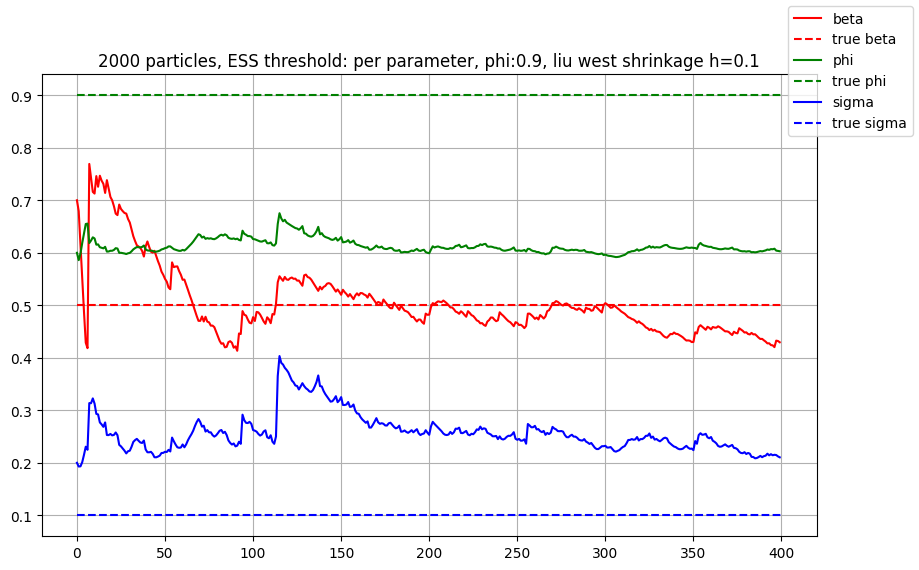

In [103]:
plot_param_estimation(guesses, N=2000, ess_threshold="per parameter, phi:0.9, liu west shrinkage h=0.1")